# Investigate thermodynamics of X-motif with MD and umbrella sampling in oxDNA

Haripin formation and hybridization between sticky ends are evaluated

X-motif design used in Corad et al Increasing valence pushes DNA nanostar networks to the isostatic point

Method to update umbrella sampling weights described in tutorial by Will Kaufhold https://github.com/WillTKaufhold1/oxdna-tutorial

In [1]:
%load_ext autoreload
%autoreload 2

# Import

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import readdy
import math
import scipy
import pandas as pd
import subprocess
import concurrent.futures

from scipy.interpolate import interp1d


# Hairpin formation

## HP formation in MD run 

In [3]:
energy_time_1,energy_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/pot_energy_1.dat", unpack=True))


Steps recorded: 50001


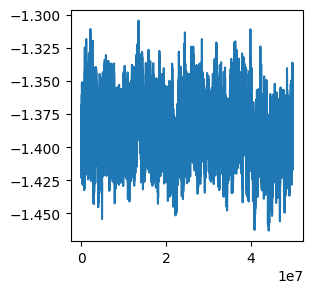

In [4]:
plt.figure(figsize=(3,3))

plt.errorbar(energy_time_1,energy_1)
print("Steps recorded:", len(energy_1))

In [5]:
t_eq=10000
#bonds in sticky ends
bonds_HP_arm1_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/HBs_arm_1_1.dat", unpack=True))[1][t_eq:]
bonds_HP_arm2_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/HBs_arm_2_1.dat", unpack=True))[1][t_eq:]
bonds_HP_arm3_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/HBs_arm_3_1.dat", unpack=True))[1][t_eq:]
bonds_HP_arm4_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/HBs_arm_4_1.dat", unpack=True))[1][t_eq:]

#time
bonds_time_1=np.asarray(np.loadtxt("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/1_motif_conf_run/files_from_haicore_x_motif_conrad_traning_data/prod_run_20_deg_150NaCl/HBs_arm_4_1.dat", unpack=True))[0][t_eq:]

#all bonds
bonds_HP_all=[bonds_HP_arm1_1,bonds_HP_arm2_1,bonds_HP_arm3_1,bonds_HP_arm4_1]

Probability for  0 bonds: 79.04739881502962 +/- 4.659964171385096 %
Probability for  1 bonds: 1.536211594710132 +/- 0.2761051953031851 %
Probability for  2 bonds: 19.41638959026024 +/- 4.384594299658145 %
Probability for 1 or 2 bonds in hairpin: 20.952601184970376 +/- 4.659964171385095 %


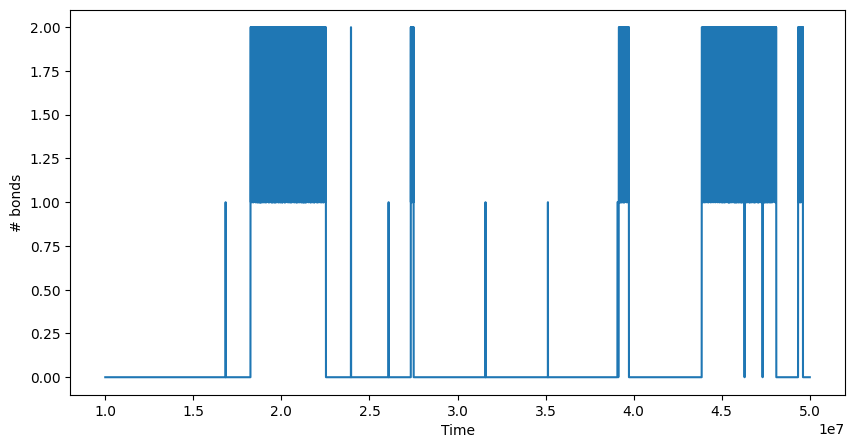

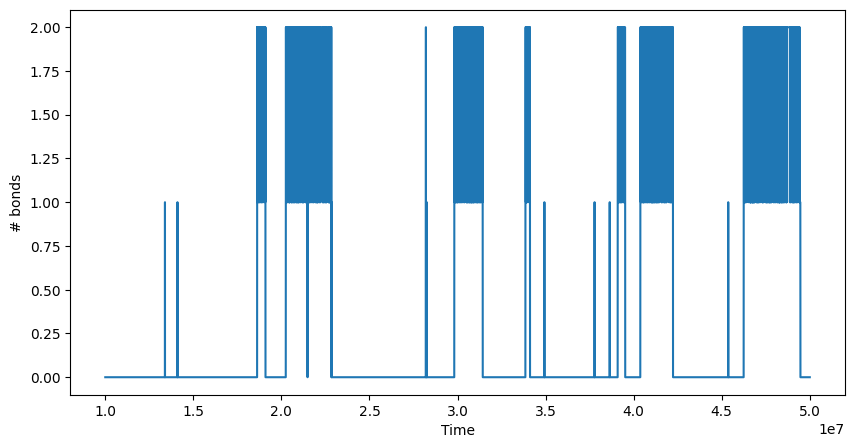

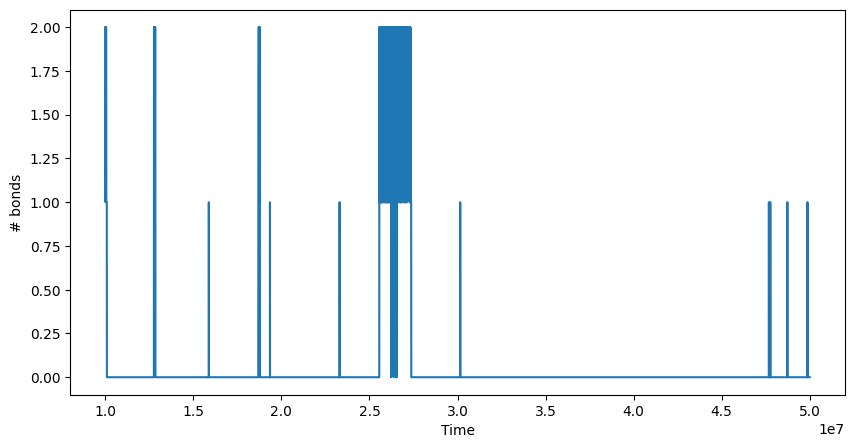

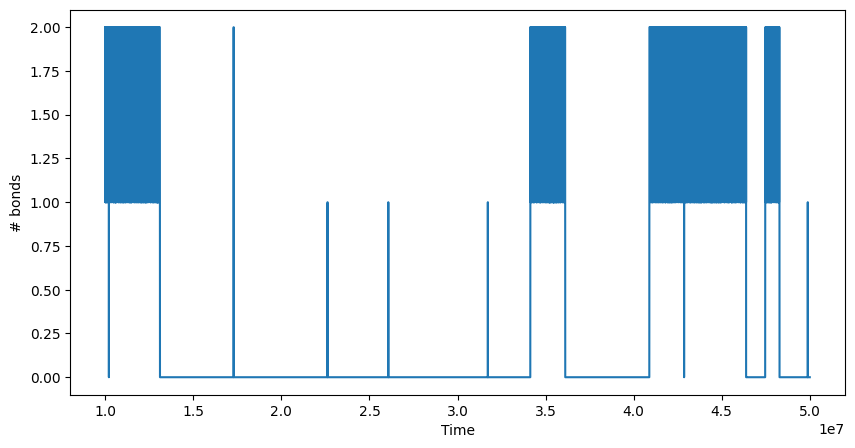

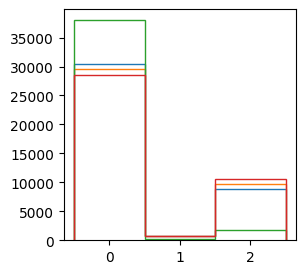

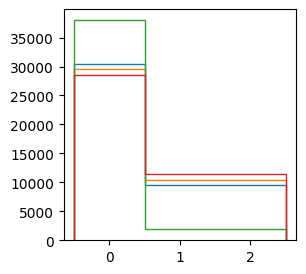

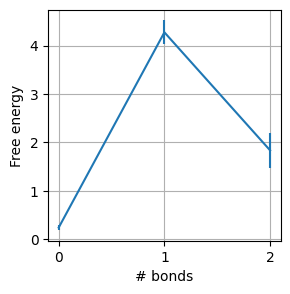

In [6]:

t1=0
t2=1000000000
for i in range(len(bonds_HP_all)):
    fig=plt.figure(figsize=(10,5))
    plt.errorbar(bonds_time_1[t1:t2],bonds_HP_all[i][t1:t2])
    plt.ylabel("# bonds")
    plt.xlabel("Time")


##list of histograms of number of bonds
bins_ba=[-0.5,0.5,1.5,2.5]
bonds_HP_all_hist=[]
plt.figure(figsize=(3,3))
for i in range(len(bonds_HP_all)):
    bonds_HP_all_hist_e=plt.hist(bonds_HP_all[i],bins=bins_ba,histtype="step")[0]
    bonds_HP_all_hist.append(bonds_HP_all_hist_e)

##list of histogram of bound/unobound
b_ub_HP_all_hist=[]
bins_b_ub=[-0.5,0.5,2.5]
plt.figure(figsize=(3,3))
for i in range(len(bonds_HP_all)):
    b_ub_HP_all_hist_e=plt.hist(bonds_HP_all[i],bins=bins_b_ub,histtype="step")[0]
    b_ub_HP_all_hist.append(b_ub_HP_all_hist_e)


#probability number of bonds
prob_bonds_HP_all=[]
log_prob_bonds_HP_all=[]
for i in range(len(bonds_HP_all_hist)): #iterate over histograms from sim runs
    prob_bonds_HP_all_e=[]
    for j in range(len(bonds_HP_all_hist[i])): #iterate over hist entries 
        prob_bonds_HP_all_e.append(bonds_HP_all_hist[i][j]/np.sum(bonds_HP_all_hist[i]))
    prob_bonds_HP_all.append(prob_bonds_HP_all_e)   
    log_prob_bonds_HP_all.append(np.log(prob_bonds_HP_all_e))

prob_bonds_HP_all=np.asarray(prob_bonds_HP_all)
log_prob_bonds_HP_all=np.asarray(log_prob_bonds_HP_all)

prob_bonds_HP_all_mean=np.mean(prob_bonds_HP_all,axis=0)
prob_bonds_HP_all_stde=np.std(prob_bonds_HP_all,axis=0)/np.sqrt(len(prob_bonds_HP_all))

log_prob_bonds_HP_all_mean=np.mean(log_prob_bonds_HP_all,axis=0)
log_prob_bonds_HP_all_stde=np.std(log_prob_bonds_HP_all,axis=0)/np.sqrt(len(log_prob_bonds_HP_all))

for i in range(len(prob_bonds_HP_all_mean)):
    print("Probability for ",i,"bonds:",prob_bonds_HP_all_mean[i]*100,"+/-",prob_bonds_HP_all_stde[i]*100,"%")

#probability bound unbound
prob_b_ub_HP_all=[]
for i in range(len(b_ub_HP_all_hist)): #iterate over histograms from sim runs
    prob_b_ub_HP_all_e=[]
    for j in range(len(b_ub_HP_all_hist[i])): #iterate over hist entries
        prob_b_ub_HP_all_e.append(b_ub_HP_all_hist[i][j]/np.sum(b_ub_HP_all_hist[j]))
    prob_b_ub_HP_all.append(prob_b_ub_HP_all_e)  

prob_b_ub_HP_all_mean=np.mean(prob_b_ub_HP_all,axis=0)
prob_b_ub_HP_all_stde=np.std(prob_b_ub_HP_all,axis=0)/np.sqrt(len(prob_b_ub_HP_all))

print("Probability for 1 or 2 bonds in hairpin:",prob_b_ub_HP_all_mean[1]*100,"+/-",prob_b_ub_HP_all_stde[1]*100,"%")

#free energy

fig=plt.figure(figsize=(3,3))
plt.errorbar([0,1,2],-log_prob_bonds_HP_all_mean,yerr=log_prob_bonds_HP_all_stde)
plt.xticks([0,1,2],[0,1,2])
plt.ylabel("Free energy")
plt.xlabel("# bonds")
plt.grid()

In [7]:
len(log_prob_bonds_HP_all)

4

# HP formation in umbrella sampling

6
weigths
0 4.25
1 1.91
2 59.00
3 4.44
1.0


/tmp/ipykernel_111/3376182716.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure(figsize=(3,3))


Text(0.5, 0, '# bonds')

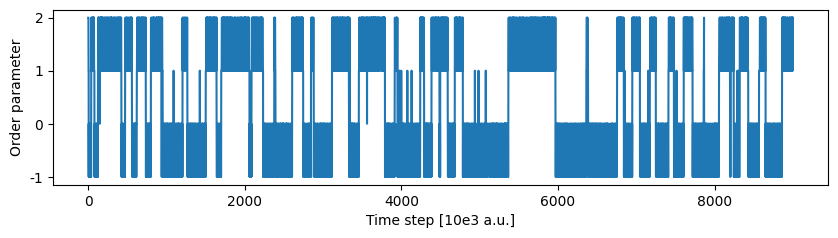

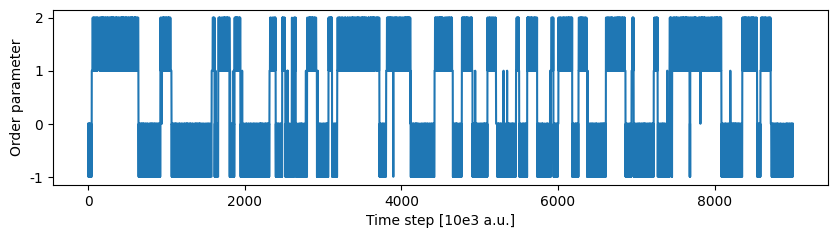

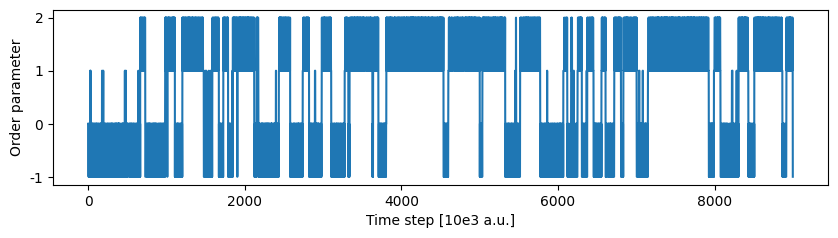

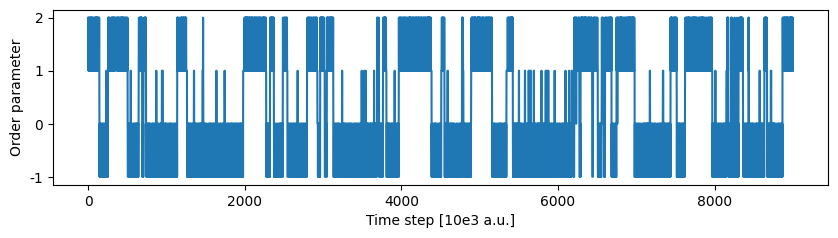

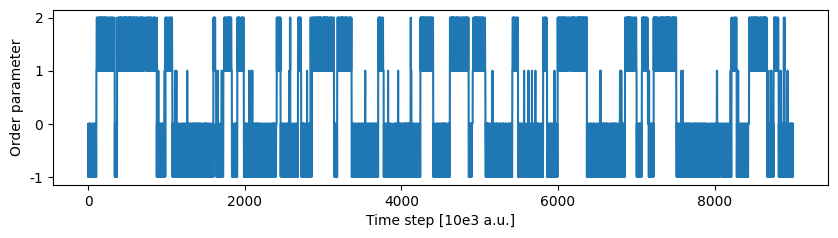

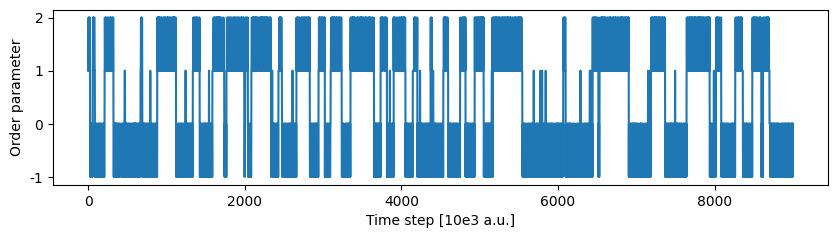

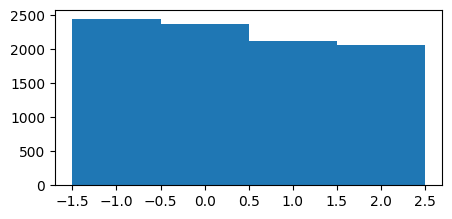

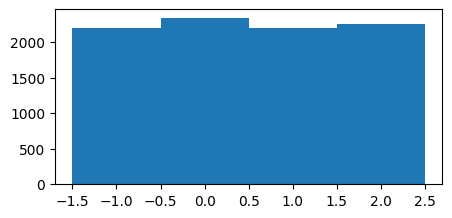

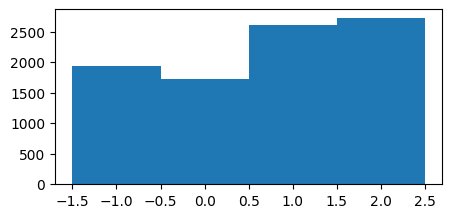

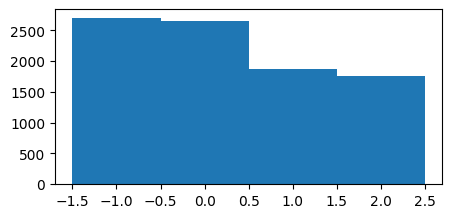

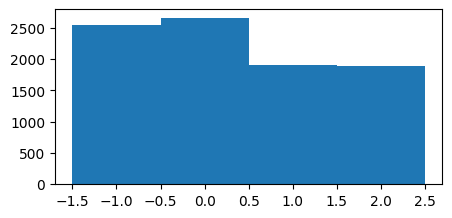

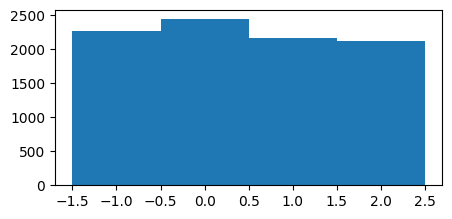

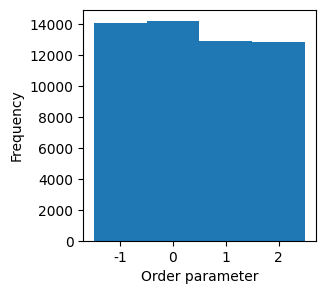

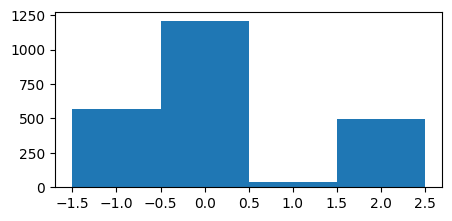

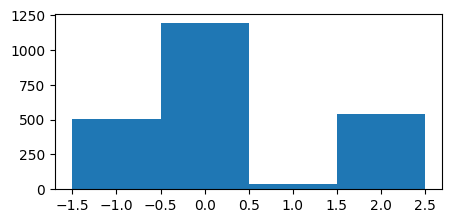

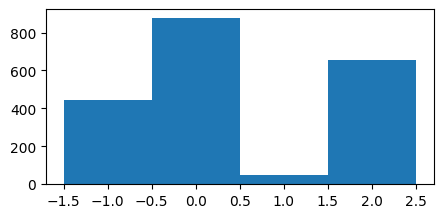

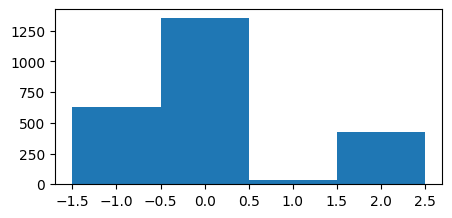

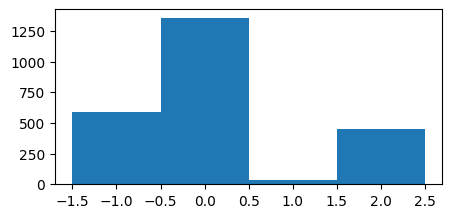

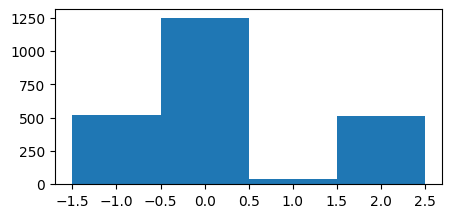

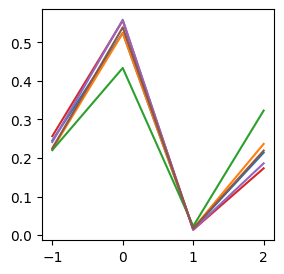

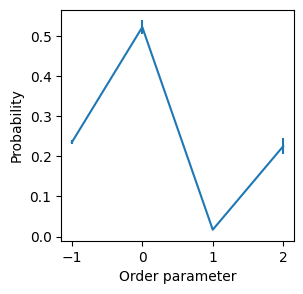

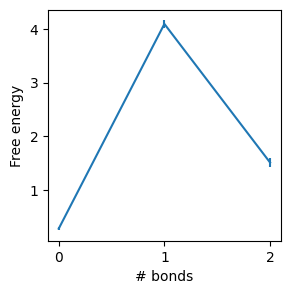

In [8]:
states_sampled_1 = []
#load simulations
for i in range(1,7):
    #read in op values and weigths
    #op_val_we = np.asarray(pd.read_fwf(f'x_motif_ortho_se/run_{i}/energy.dat',header = None)[[5,6,7]])[1000:]
    #op_val_we = np.asarray(pd.read_fwf(f'/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_HP/run_a_{i}/energy.dat',header = None)[[5,6,7]])[1000:]
    op_val_we = np.asarray(pd.read_fwf(f'/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_HP/Kreysing_workstation/run_b_{i}/energy.dat',header = None)[[5,6,7]])[1000:]

    #trf op values to scale from -3 to 4 
    op_val_trf = -op_val_we[:,1]+op_val_we[:,0]
    #weights 
    op_we = op_val_we[:,2]
    states_sampled_1.append([op_val_trf,op_we])
#plot states visited
for i in range(len(states_sampled_1)):
    #ax[i].plot(data_set[i][0])
    fig=plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(211)
    plt.plot(states_sampled_1[i][0])
    plt.yticks([-1,0,1,2] ,[-1,0,1,2])
    plt.xlabel("Time step [10e3 a.u.]")
    plt.ylabel("Order parameter")


#histogram of states visited
for i in range(len(states_sampled_1)):
    fig=plt.figure(figsize=(5,5))
    ax1 = fig.add_subplot(211)
    hist1=plt.hist(states_sampled_1[i][0],bins = np.arange(-1.5,3,1))

#histigram of al states in all simulations
fig=plt.figure(figsize=(3,3))
ax1 = fig.add_subplot()
all_states_sampled_1=[]
for i in range(len(states_sampled_1)):
    all_states_sampled_1.append(states_sampled_1[i][0])
all_states_sampled_1=np.asarray(all_states_sampled_1).flatten()   
hist1_all=plt.hist(all_states_sampled_1,bins = np.arange(-1.5,3,1))
plt.xticks([-1,0,1,2] ,[-1,0,1,2])
plt.ylabel("Frequency")
plt.xlabel("Order parameter")

#get frequency of visits with correct weighting
unbiased_freq_1=[]
for i in range(len(states_sampled_1)):
    fig=plt.figure(figsize=(5,5))
    ax1 = fig.add_subplot(211)
    unbiased_freq_1.append(plt.hist(states_sampled_1[i][0],bins = np.arange(-1.5,3,1),weights=1/states_sampled_1[i][1])[0] )



#convert to probability
unbiased_prob_1 = []
fig=plt.figure(figsize=(3,3))
for i in unbiased_freq_1:
    
    plt.errorbar([-1,0,1,2],i/sum(i))
    unbiased_prob_1.append(i/sum(i))
print(len(unbiased_prob_1))
#print("weights:", 1/np.mean(unbiased_prob_1,axis = 0) )
#print("weights:", 1/np.mean(unbiased_prob_1,axis = 0) )
weights_list=1/np.mean(unbiased_prob_1,axis = 0)
print("weigths")
for i in range(len(weights_list)):
    print(i,"{:.2f}".format(weights_list[i]))



fig=plt.figure(figsize=(3,3))

plt.errorbar([-1,0,1,2],np.mean(unbiased_prob_1,axis=0), yerr=np.std(unbiased_prob_1,axis=0)/np.sqrt(len(unbiased_prob_1))  )
plt.ylabel("Probability")
plt.xlabel("Order parameter")
print(np.sum(np.mean(unbiased_prob_1,axis=0)))




prob_bonds_1=[]

log_prob_bonds_1=[]
for i in range(len(unbiased_prob_1)):
    prob_bonds_1_e=[ np.sum(unbiased_prob_1[i][:2]) , *unbiased_prob_1[i][2:] ]
    prob_bonds_1.append(prob_bonds_1_e)   
    log_prob_bonds_1.append(np.log(prob_bonds_1_e))

prob_bonds_1=np.asarray(prob_bonds_1)
log_prob_bonds_1=np.asarray(log_prob_bonds_1)


fig=plt.figure(figsize=(3,3))
plt.errorbar(np.arange(0,len(log_prob_bonds_1[0])),np.mean(-log_prob_bonds_1,axis=0),yerr=np.std(-log_prob_bonds_1,axis=0 )/np.sqrt(len( log_prob_bonds_1) ))
plt.xticks([0,1,2],[0,1,2])
plt.ylabel("Free energy")
plt.xlabel("# bonds")

In [9]:
#probability to be in hairpin with 1-3 bonds
prob_bound_total=[]
for i in range(len(prob_bonds_1)):
    prob_e=np.sum(prob_bonds_1[i][1:])
    prob_bound_total.append(prob_e)
    #print(prob_e)

print("Probability for 1 or 2 bonds in hairpin", np.mean(prob_bound_total)*100 ,"+/-", np.std(prob_bound_total)/np.sqrt(len(prob_bound_total))*100,"%")

Probability for 1 or 2 bonds in hairpin 24.226955918976063 +/- 2.102989269246678 %


In [10]:
prob_bonds_1

array([[0.76959539, 0.01646296, 0.21394166],
       [0.74620766, 0.01733604, 0.2364563 ],
       [0.65383192, 0.0231671 , 0.32300098],
       [0.8129223 , 0.01384142, 0.17323628],
       [0.79976025, 0.01412098, 0.18611876],
       [0.76406513, 0.01675976, 0.21917511]])

In [11]:
# List of folders
folder_path="/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_HP/"

folders = ['run_a_1', 'run_a_2', 'run_a_3','run_a_4', 'run_a_5', 'run_a_6']

folder_paths=[folder_path+e for e in folders]

# Command to run
chmod_command="chmod +x oxDNA"
run_command = './oxDNA input'

def execute_commands(folder, chmod_command, run_command):
    # Change directory and make the script executable
    chmod_result = subprocess.run(chmod_command, shell=True, cwd=folder, capture_output=True, text=True)
    if chmod_result.stderr:
        print(f"Error making script executable in {folder}:\n{chmod_result.stderr}")
    
    # Run the program
    run_result = subprocess.run(run_command, shell=True, cwd=folder, capture_output=True, text=True)
    print(f"Output for {folder}:\n{run_result.stdout}")
    if run_result.stderr:
        print(f"Error running script in {folder}:\n{run_result.stderr}")



# Use ThreadPoolExecutor to run commands in parallel
def parallel_run_oxDNA(folders,chmod_command, run_command):
    with concurrent.futures.ThreadPoolExecutor() as executor:
        executor.map(lambda folder: execute_commands(folder, chmod_command, run_command), folders)


In [12]:
#parallel_run_oxDNA(folders=folder_paths,chmod_command=chmod_command, run_command=run_command)

<Figure size 300x300 with 0 Axes>

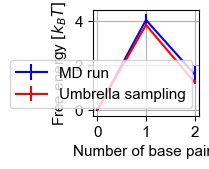

In [10]:
fig=plt.figure(figsize=(3,3))
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 

#plt.errorbar(np.arange(0,len(log_prob_bonds_HP_all[0])),np.mean(-log_prob_bonds_HP_all,axis=0),yerr=np.std(-log_prob_bonds_HP_all,axis=0 )/np.sqrt(len( log_prob_bonds_HP_all) ),label="X-motif",color="green")
plt.errorbar(np.arange(0,len(log_prob_bonds_HP_all[0])),np.mean(-log_prob_bonds_HP_all,axis=0)-np.mean(-log_prob_bonds_HP_all,axis=0)[0],yerr=np.std(-log_prob_bonds_HP_all ,axis=0)/np.sqrt(len( log_prob_bonds_HP_all) ) ,label="MD run",color="blue")

plt.errorbar(np.arange(0,len(log_prob_bonds_1[0])),np.mean(-log_prob_bonds_1,axis=0)-np.mean(-log_prob_bonds_1,axis=0)[0],yerr=np.std(-log_prob_bonds_1 ,axis=0)/np.sqrt(len( log_prob_bonds_1) ) ,label="Umbrella sampling",color="red")
plt.xticks([0,1,2],[0,1,2],fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel(r"Free energy $[k_B T]$",fontname = "Arial",fontsize=11)
plt.xlabel("Number of base pairs",fontname = "Arial",fontsize=11)
#plt.ylim(-2,6.5)
plt.grid()
plt.legend(prop={'family': 'Arial','size': 11})
#plt.savefig("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/figures/free_energy_HP_MD_umbr_1.pdf",format="pdf",bbox_inches="tight")


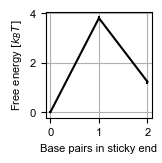

In [14]:
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

plt.errorbar(np.arange(0,len(log_prob_bonds_1[0])),np.mean(-log_prob_bonds_1,axis=0)-np.mean(-log_prob_bonds_1,axis=0)[0],yerr=np.std(-log_prob_bonds_1 ,axis=0)/np.sqrt(len( log_prob_bonds_1) ) ,label="Umbrella sampling",color="black")


fs1=8
#plt.xlim(-1,110)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel(r"Free energy $[k_B T]$",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Base pairs in sticky end",fontname = "Arial",fontsize=fs1)
plt.xticks([0,1,2],[0,1,2],fontname = "Arial",fontsize=fs1)
plt.yticks([0,2,4],fontname = "Arial",fontsize=fs1)
ax1.grid()
#plt.savefig("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/figures/free_energy_HP_2.pdf",format="pdf",bbox_inches="tight")


# Sticky end hybridisation

In [3]:
# List of folders
folder_path_SE="/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/"

folders_SE = ['run_d_1', 'run_d_2', 'run_d_3','run_d_4', 'run_d_5', 'run_d_6']

folder_paths_SE=[folder_path_SE+e for e in folders_SE]

# Command to run
chmod_command_SE="chmod +x oxDNA"
run_command_SE = './oxDNA input'

In [4]:
# code to run oxDNA simulations from jupyter cell
def execute_commands(folder, chmod_command, run_command):
    # Change directory and make the script executable
    chmod_process = subprocess.Popen(chmod_command, shell=True, cwd=folder, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    for line in iter(chmod_process.stderr.readline, ''):
        print(f"Error making script executable in {folder}:\n{line.strip()}")
    chmod_process.wait()

    # Run the program
    run_process = subprocess.Popen(run_command, shell=True, cwd=folder, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    for line in iter(run_process.stdout.readline, ''):
        print(f"Output for {folder}:\n{line.strip()}")
    for line in iter(run_process.stderr.readline, ''):
        print(f"Error running script in {folder}:\n{line.strip()}")
    run_process.wait()

def parallel_run_oxDNA(folders, chmod_command, run_command):
    with concurrent.futures.ThreadPoolExecutor() as executor:
        executor.map(lambda folder: execute_commands(folder, chmod_command, run_command), folders)


In [5]:
%%time
parallel_run_oxDNA(folders=folder_paths_SE,chmod_command=chmod_command_SE, run_command=run_command_SE)

Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_1:
0  -1.131115   0.637  0.538  0.000   0  0 161065.440000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_1:
1000  -1.159347   0.620  0.529  0.000   1  0 3083846.910000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_3:
0  -1.114360   0.567  0.519  0.000   1  0 3083846.910000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_2:
0  -1.228222   0.479  0.474  0.000   2  0 113484.040000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_4:
0  -1.184037   0.527  0.471  0.000   0  0 161065.440000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_3:
1000  -1.195382   0.559  0.516  0.000   1  0 3083846.910000
Output for /home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_1:
2000  -1.198634   0.620  

6
weigths
0 58.75
1 178000.01
2 3270456.27
3 99454.03
4 12118.48
5 635.12
6 17.76
7 1.08
1.0


/tmp/ipykernel_50/1425754823.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure(figsize=(3,3))


Text(0.5, 0, '# bonds')

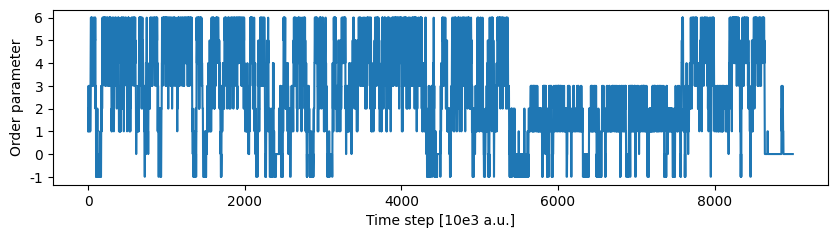

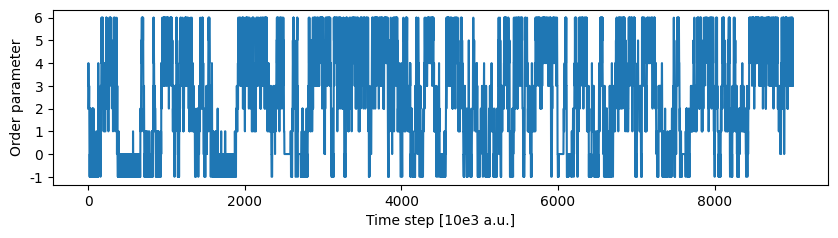

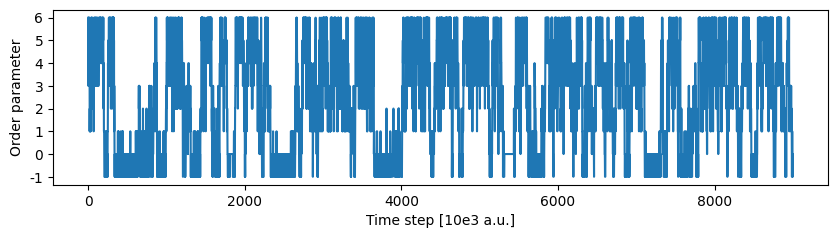

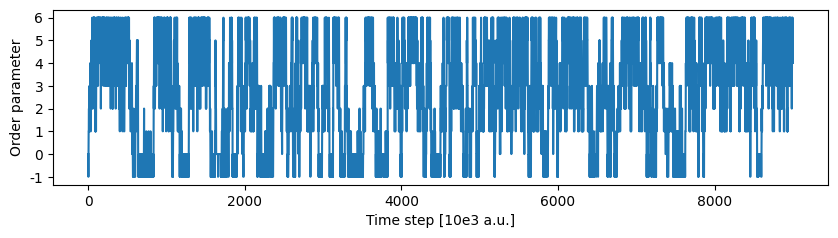

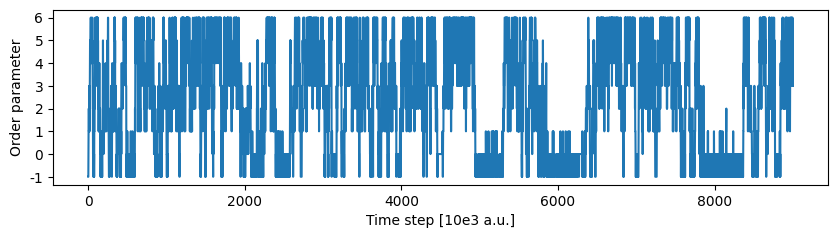

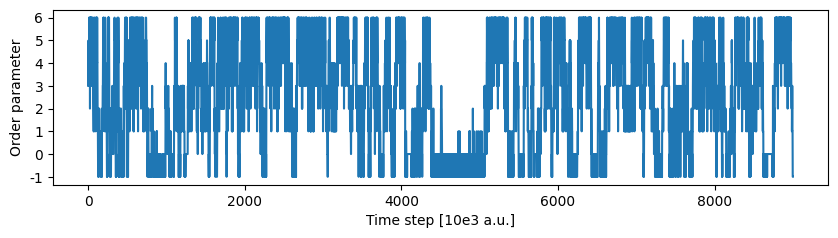

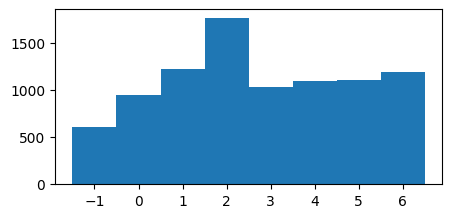

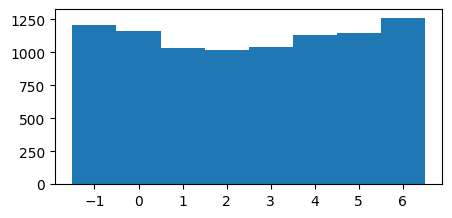

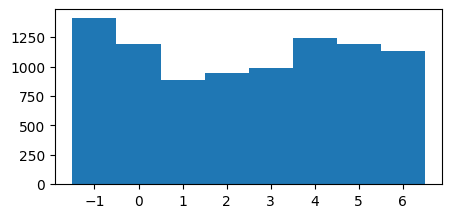

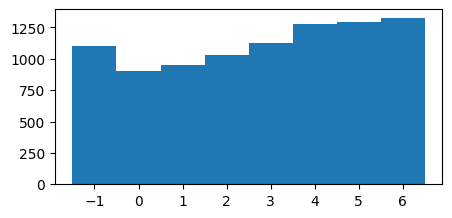

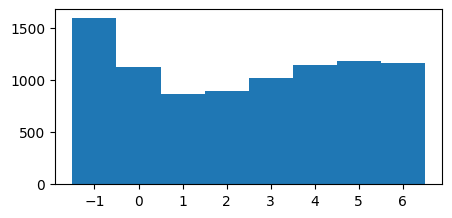

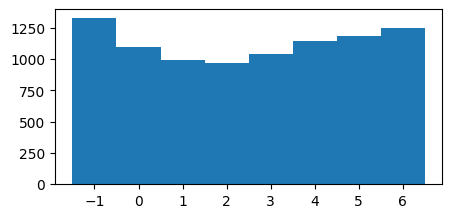

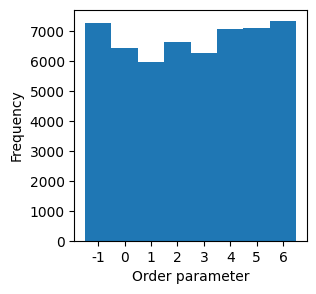

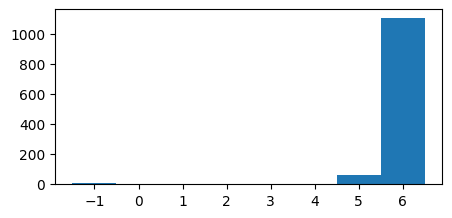

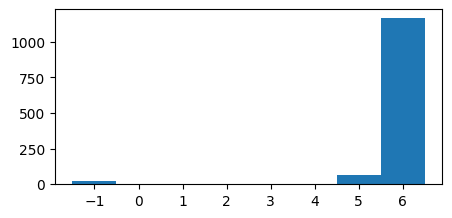

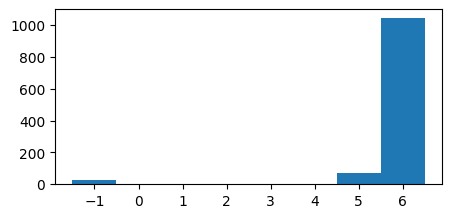

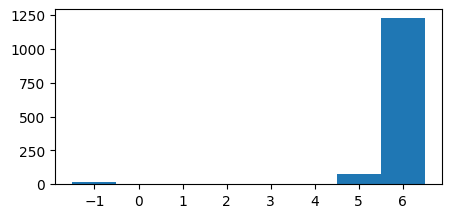

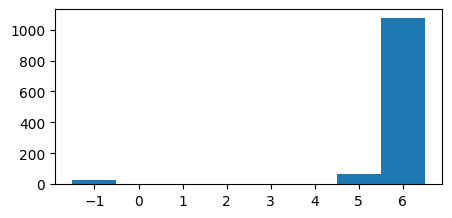

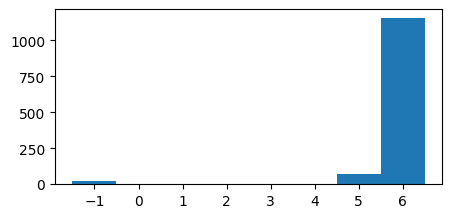

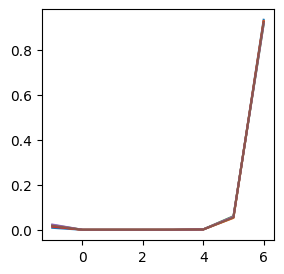

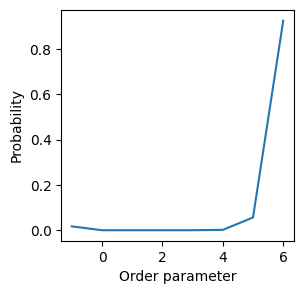

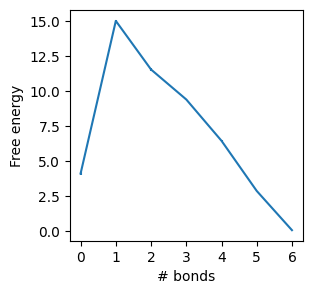

In [12]:
states_sampled_2 = []
#load simulations
for i in range(1,7):
    #read in op values and weigths
    #op_val_we = np.asarray(pd.read_fwf(f'/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_{i}/energy.dat',header = None)[[5,6,7]])[1000:]
    #op_val_we = np.asarray(pd.read_fwf(f'/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_{i}/energy.dat',header = None)[[5,6,7]])[:]
    op_val_we = np.asarray(pd.read_fwf(f'/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_{i}/energy.dat',header = None)[[5,6,7]])[1000:]

    #trf op values to scale from -3 to 4 
    op_val_trf = -op_val_we[:,1]+op_val_we[:,0]
    #weights 
    op_we = op_val_we[:,2]
    states_sampled_2.append([op_val_trf,op_we])
#plot states visited
for i in range(len(states_sampled_2)):
    #ax[i].plot(data_set[i][0])
    fig=plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(211)
    plt.plot(states_sampled_2[i][0])
    plt.yticks([-1,0,1,2,3,4,5,6] ,[-1,0,1,2,3,4,5,6])
    plt.xlabel("Time step [10e3 a.u.]")
    plt.ylabel("Order parameter")


#histogram of states visited
for i in range(len(states_sampled_2)):
    fig=plt.figure(figsize=(5,5))
    ax1 = fig.add_subplot(211)
    hist1=plt.hist(states_sampled_2[i][0],bins = np.arange(-1.5,7,1))

#histigram of al states in all simulations
fig=plt.figure(figsize=(3,3))
ax1 = fig.add_subplot()
all_states_sampled_2=[]
for i in range(len(states_sampled_2)):
    all_states_sampled_2.append(states_sampled_2[i][0])
all_states_sampled_2=np.asarray(all_states_sampled_2).flatten()   
hist1_all=plt.hist(all_states_sampled_2,bins = np.arange(-1.5,7,1))
plt.xticks([-1,0,1,2,3,4,5,6] ,[-1,0,1,2,3,4,5,6])
plt.ylabel("Frequency")
plt.xlabel("Order parameter")

#get frequency of visits with correct weighting
unbiased_freq_2=[]
for i in range(len(states_sampled_2)):
    fig=plt.figure(figsize=(5,5))
    ax1 = fig.add_subplot(211)
    unbiased_freq_2.append(plt.hist(states_sampled_2[i][0],bins = np.arange(-1.5,7,1),weights=1/states_sampled_2[i][1])[0] )



#convert to probability
unbiased_prob_2 = []
fig=plt.figure(figsize=(3,3))
for i in unbiased_freq_2:
    
    plt.errorbar([-1,0,1,2,3,4,5,6],i/sum(i))
    unbiased_prob_2.append(i/sum(i))
print(len(unbiased_prob_2))
#print("weights:", 1/np.mean(unbiased_prob_2,axis = 0) )
#print("weights:", 1/np.mean(unbiased_prob_2,axis = 0) )
weights_list_2=1/np.mean(unbiased_prob_2,axis = 0)
print("weigths")
for i in range(len(weights_list_2)):
    print(i,"{:.2f}".format(weights_list_2[i]))



fig=plt.figure(figsize=(3,3))

plt.errorbar([-1,0,1,2,3,4,5,6],np.mean(unbiased_prob_2,axis=0), yerr=np.std(unbiased_prob_2,axis=0)/np.sqrt(len(unbiased_prob_2))  )
plt.ylabel("Probability")
plt.xlabel("Order parameter")
print(np.sum(np.mean(unbiased_prob_2,axis=0)))




prob_bonds_2=[]

log_prob_bonds_2=[]
for i in range(len(unbiased_prob_2)):
    prob_bonds_2_e=[ np.sum(unbiased_prob_2[i][:2]) , *unbiased_prob_2[i][2:] ]
    prob_bonds_2.append(prob_bonds_2_e)   
    log_prob_bonds_2.append(np.log(prob_bonds_2_e))

prob_bonds_2=np.asarray(prob_bonds_2)
log_prob_bonds_2=np.asarray(log_prob_bonds_2)


fig=plt.figure(figsize=(3,3))
plt.errorbar(np.arange(0,len(log_prob_bonds_2[0])),np.mean(-log_prob_bonds_2,axis=0),yerr=np.std(-log_prob_bonds_2,axis=0 )/np.sqrt(len( log_prob_bonds_2) ))
plt.xticks([0,1,2,3,4,5,6],[0,1,2,3,4,5,6])
plt.ylabel("Free energy")
plt.xlabel("# bonds")

In [13]:
#probability to be hybridized with 1-6 bonds
prob_bound_total_2=[]
for i in range(len(prob_bonds_2)):
    prob_e=np.sum(prob_bonds_2[i][1:])
    prob_bound_total_2.append(prob_e)
    #print(prob_e)

print("Probability for 1-6 bonds between two SEs", np.mean(prob_bound_total_2)*100 ,"+/-", np.std(prob_bound_total_2)/np.sqrt(len(prob_bound_total_2))*100,"%")

Probability for 1-6 bonds between two SEs 98.29729701114616 +/- 0.19264912972552461 %


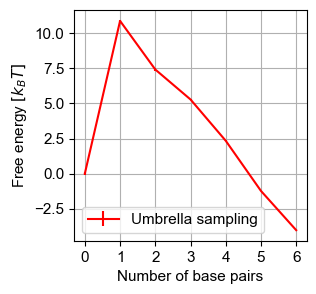

In [14]:
fig=plt.figure(figsize=(3,3))
#plt.errorbar(np.arange(0,len(log_prob_bonds_HP_all[0])),np.mean(-log_prob_bonds_HP_all,axis=0),yerr=np.std(-log_prob_bonds_HP_all,axis=0 )/np.sqrt(len( log_prob_bonds_HP_all) ),label="X-motif",color="green")
plt.errorbar(np.arange(0,len(log_prob_bonds_2[0])),np.mean(-log_prob_bonds_2,axis=0)-np.mean(-log_prob_bonds_2,axis=0)[0],yerr=np.std(-log_prob_bonds_2 ,axis=0)/np.sqrt(len( log_prob_bonds_2) ) ,label="Umbrella sampling",color="red")

plt.xticks([0,1,2,3,4,5,6],[0,1,2,3,4,5,6],fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel(r"Free energy $[k_B T]$",fontname = "Arial",fontsize=11)
plt.xlabel("Number of base pairs",fontname = "Arial",fontsize=11)
#plt.ylim(-2,6.5)
plt.grid()
plt.legend(prop={'family': 'Arial','size': 11})

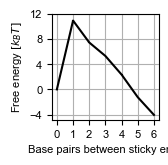

In [15]:
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

plt.errorbar(np.arange(0,len(log_prob_bonds_2[0])),np.mean(-log_prob_bonds_2,axis=0)-np.mean(-log_prob_bonds_2,axis=0)[0],yerr=np.std(-log_prob_bonds_2 ,axis=0)/np.sqrt(len( log_prob_bonds_2) ) ,label="Umbrella sampling",color="black")


fs1=8
#plt.xlim(-1,110)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel(r"Free energy $[k_B T]$",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Base pairs between sticky ends",fontname = "Arial",fontsize=fs1)
plt.xticks([0,1,2,3,4,5,6],fontname = "Arial",fontsize=fs1)
plt.yticks([-4,0,4,8,12],fontname = "Arial",fontsize=fs1)
ax1.grid()
#plt.savefig("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/figures/free_energy_SE_hybr_2.pdf",format="pdf",bbox_inches="tight")


In [16]:
log_prob_b_ub=[]
prob_b_ub=[]
for i in range(len(unbiased_prob_2)):
    prob_b_ub_e=[ np.sum(unbiased_prob_2[i][:2]) , np.sum(unbiased_prob_2[i][2:]) ]
    prob_b_ub.append(prob_b_ub_e)   
    log_prob_b_ub.append(np.log(prob_b_ub_e))
log_prob_b_ub=np.asarray(log_prob_b_ub)
prob_b_ub=np.asarray(prob_b_ub)

In [17]:
print(log_prob_b_ub)

[[-4.73033562 -0.00886267]
 [-4.11161081 -0.01651702]
 [-3.85311023 -0.0214419 ]
 [-4.25231045 -0.01433355]
 [-3.76016747 -0.0235551 ]
 [-4.00454994 -0.01840075]]


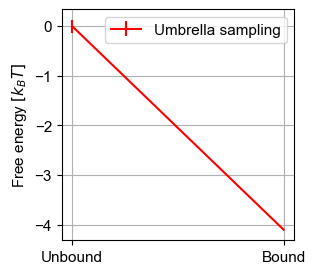

In [18]:
fig=plt.figure(figsize=(3,3))
#plt.errorbar(np.arange(0,len(log_prob_bonds_HP_all[0])),np.mean(-log_prob_bonds_HP_all,axis=0),yerr=np.std(-log_prob_bonds_HP_all,axis=0 )/np.sqrt(len( log_prob_bonds_HP_all) ),label="X-motif",color="green")
plt.errorbar(np.arange(0,len(log_prob_b_ub[0])),np.mean(-log_prob_b_ub,axis=0)-np.mean(-log_prob_b_ub,axis=0)[0],yerr=np.std(-log_prob_b_ub ,axis=0)/np.sqrt(len( log_prob_b_ub) ) ,label="Umbrella sampling",color="red")

plt.xticks([0,1],["Unbound","Bound"],fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel(r"Free energy $[k_B T]$",fontname = "Arial",fontsize=11)
#plt.xlabel("Number of base pairs",fontname = "Arial",fontsize=11)
#plt.ylim(-2,6.5)
plt.grid()
plt.legend(prop={'family': 'Arial','size': 11})

In [19]:
print("Probablity unbound/bound", np.mean(prob_b_ub, axis=0))
print("Free energy unbound/bound",np.mean(log_prob_b_ub, axis=0))

dF_b_ub=np.abs(np.mean(log_prob_b_ub, axis=0)[0]) -np.abs(np.mean(log_prob_b_ub, axis=0)[1])
dF_b_ub_stde=np.sqrt(  (np.std(log_prob_b_ub, axis=0)[0]/len(log_prob_b_ub))**2 + (np.std(log_prob_b_ub, axis=0)[1]/len(log_prob_b_ub))**2     )
print("Difference free energy unbound/bound",dF_b_ub,"+/-",dF_b_ub_stde  )

Probablity unbound/bound [0.01702703 0.98297297]
Free energy unbound/bound [-4.11868075 -0.01718517]
Difference free energy unbound/bound 4.101495587579587 +/- 0.05289104348022941


# Get melting curve

In [20]:

#last_hist_load=pd.read_csv("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_1/last_hist.dat",sep=" ",comment="#")
#last_hist_load=pd.read_table("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_1/last_hist.dat",sep=" ",usecols=range(27))[:8]
#last_hist_load=pd.read_table("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_1/last_hist.dat",sep=" ",usecols=range(28))[:8]
last_hist_load=pd.read_table("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_1/last_hist.dat",sep=" ",usecols=range(28))[:8]


last_hist_load.columns =["op1","op2","b20C","20C","1","4C","7C","10C","13C","16C","19C","22C","25C","28C","31C","34C","37C","40C","43C","46C","49C","52C","55C","58C","61C","64C","67C","70C"]

final_temps=np.asarray([20,1,4,7,10,13,16,19,22,25,28,31,34,37,40,43,46,49,52,55,58,61,64,67,70])

In [21]:
#in the histogram, state 0,0 and stante 0,1 both correspond to zero base pairs. As a reference we therefore need the sum of these states.
last_hist_load

,op1,op2,b20C,20C,1,4C,7C,10C,13C,16C,...,43C,46C,49C,52C,55C,58C,61C,64C,67C,70C
0,0,0,37395500.0,2.384860e+02,2.064930e+16,7.303510e+13,3.153660e+11,1.684400e+09,1.128400e+07,9.571200e+04,...,1.615370e-10,7.792320e-12,4.180350e-13,2.467230e-14,1.586710e-15,1.102840e-16,8.227460e-18,6.550200e-19,5.538570e-20,4.953880e-21
1,1,0,49180500.0,1.849970e+01,1.730080e+15,6.821670e+12,3.168220e+10,1.738410e+08,1.133300e+06,8.851530e+03,...,5.477700e-12,2.425810e-13,1.189390e-14,6.394720e-16,3.739930e-17,2.363290e-18,1.604320e-19,1.164270e-20,8.994210e-22,7.369110e-23
2,2,0,71363400.0,7.913980e+02,1.504960e+17,5.237390e+14,2.164940e+12,1.065410e+10,6.261470e+07,4.408840e+05,...,5.492380e-11,2.053770e-12,8.671650e-14,4.088060e-15,2.129430e-16,1.214250e-17,7.519180e-19,5.021960e-20,3.596600e-21,2.748390e-22
3,3,0,45445900.0,4.400330e+03,3.591200e+18,1.015370e+16,3.369000e+13,1.314190e+11,6.060210e+08,3.338250e+06,...,1.217860e-10,3.953800e-12,1.424860e-13,5.659800e-15,2.463150e-16,1.168220e-17,6.009080e-19,3.337340e-20,1.993000e-21,1.274820e-22
4,4,0,48026800.0,7.867840e+04,1.975500e+20,4.763490e+17,1.340190e+15,4.399370e+12,1.691990e+10,7.709010e+07,...,8.712220e-10,2.546430e-11,8.244260e-13,2.937560e-14,1.145520e-15,4.864130e-17,2.238720e-18,1.112130e-19,5.940060e-21,3.399110e-22
5,5,0,48466600.0,2.817820e+06,1.451840e+22,3.125240e+19,7.855830e+16,2.305040e+14,7.922920e+11,3.222830e+09,...,1.303770e-08,3.414030e-10,9.890330e-12,3.149550e-13,1.096670e-14,4.156380e-16,1.707760e-17,7.580020e-19,3.622910e-20,1.859180e-21
6,6,0,50159600.0,4.644410e+07,4.493020e+23,8.734440e+20,1.984750e+18,5.270270e+15,1.641380e+13,6.055800e+10,...,7.531050e-08,1.686400e-09,4.181570e-11,1.141770e-12,3.416970e-14,1.116120e-15,3.963790e-17,1.524950e-18,6.333510e-20,2.830400e-21
7,0,1,26161600.0,4.478190e+05,3.017200e+19,1.237440e+17,5.992630e+14,3.441390e+12,2.361350e+10,1.956230e+08,...,1.646820e-07,7.139500e-09,3.422420e-10,1.799840e-11,1.031120e-12,6.394570e-14,4.268500e-15,3.051470e-16,2.325800e-17,1.882540e-18


In [22]:
#all non bonded states
ref_no_bonds=last_hist_load.iloc[0]+last_hist_load.iloc[7]
ref_no_bonds=pd.DataFrame([ref_no_bonds])

#all bonded states
ref_bonds=last_hist_load.iloc[1]+last_hist_load.iloc[2]+last_hist_load.iloc[3]+last_hist_load.iloc[4]+last_hist_load.iloc[5]+last_hist_load.iloc[6]
ref_bonds=pd.DataFrame([ref_bonds])

#all states
ref_all=ref_bonds.iloc[0]+last_hist_load.iloc[0]+last_hist_load.iloc[7]
ref_all=pd.DataFrame([ref_all])

fraction_bonded=ref_bonds.iloc[0]/ref_all.iloc[0]
fraction_bonded=pd.DataFrame([fraction_bonded])


ratio_bonded=ref_bonds.iloc[0]/ref_no_bonds.iloc[0]
ratio_bonded=pd.DataFrame([ratio_bonded])


In [23]:
def correction_melting_curve_identical_particles(phi):
    f_inf=(1 + 1/(4*phi)) - np.sqrt( (1 + 1/(4*phi))**2 -1 )
    return np.asarray(f_inf)

In [24]:
f_inf=correction_melting_curve_identical_particles(phi=ratio_bonded.iloc[0, 3:].to_numpy())

sorted_indices = np.argsort(final_temps)

f_inf=f_inf[sorted_indices]
final_temps_s=final_temps[sorted_indices]

f_1=fraction_bonded.iloc[0, 3:].to_numpy()[sorted_indices]

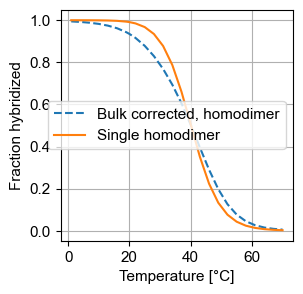

In [25]:

fig=plt.figure(figsize=(3,3))
plt.errorbar(final_temps_s,f_inf,label="Bulk corrected, homodimer",fmt="--")

plt.errorbar(final_temps_s,f_1,label="Single homodimer")

plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel(r"Fraction hybridized",fontname = "Arial",fontsize=11)
plt.xlabel("Temperature [°C]",fontname = "Arial",fontsize=11)
#plt.ylim(-2,6.5)
plt.grid()
plt.legend(prop={'family': 'Arial','size': 11})

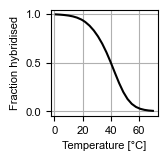

In [26]:
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

plt.errorbar(final_temps_s,f_inf,label="Bulk corrected, homodimer",fmt="-",color="black")

fs1=8
#plt.xlim(-1,110)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel(r"Fraction hybridised",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Temperature [°C]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,20,40,60],fontname = "Arial",fontsize=fs1)
plt.yticks([0.0,0.5,1.0],fontname = "Arial",fontsize=fs1)
ax1.grid()
#plt.savefig("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/figures/metling_curve_SE_hybr_1.pdf",format="pdf",bbox_inches="tight")


In [27]:


interp_func_bulk_corr = interp1d(f_inf,final_temps_s, kind='linear', fill_value="extrapolate")
print("melting temp bulk corrected:",interp_func_bulk_corr(0.5))


interp_func_no_bulk_corr = interp1d(f_1,final_temps_s, kind='linear', fill_value="extrapolate")
print("melting not temp bulk corrected:",interp_func_no_bulk_corr(0.5))


melting temp bulk corrected: 40.11222726055324
melting not temp bulk corrected: 40.11806232663107


In [28]:
interp_func_bulk_corr2 = interp1d(final_temps_s,f_inf, kind='linear', fill_value="extrapolate")
print("fraction hybr. 20°C, bulk corrected:",interp_func_bulk_corr2(20))


interp_func_no_bulk_corr2 = interp1d(final_temps_s,f_1, kind='linear', fill_value="extrapolate")
print("fraction hybr. 20°C, not bulk corrected:",interp_func_no_bulk_corr2(20))

fraction hybr. 20°C, bulk corrected: 0.9348524234162796
fraction hybr. 20°C, not bulk corrected: 0.991001753409207


In [29]:

#evaluate melting curve and interpolate for target fraction and temperature for homodimers
def melting_curve_eval_homo_dim(load_files,use_cols,use_rows,final_temps,non_bonded_states,all_bonded_states,all_states,skip_cols_in_last_hist,target_fraction,target_temp):
    #load_files: list of files to load in
    #use_cols: how many columns are usable
    #use_rows: how many rows are usable
    #final_temps: temerpatures during sim and extrapolated (not necessarily ordered by increasing temperature )
    #non_bonded_states: indices of non-bonded states. Can be unbound close and unound far
    #all_bonded_states: all indices of bonded states. E.g. 1,2,3,...
    #all_states: all states bonded and non-bonded
    #skip_cols_in_last_hist: how many columns in last_hist to skip (i.e. order parameter, non-normalized state count)
    #target_fraction: for this target fraction, the temperature will be interpolated
    #target_temp: for this target temperature the fraction of hybridized strands will be interpolated
    
    all_f_inf=[]
    all_f_1=[]

    return_fraction=[]
    return_fraction_corr=[]
    return_temp=[]
    return_temp_corr=[]
    
    for i in range(len(load_files)):
    
        #last_hist_load=pd.read_csv("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_1/last_hist.dat",sep=" ",comment="#")
        last_hist_load=pd.read_table(load_files[i],sep=" ",usecols=range(use_cols))[:use_rows]  
        
        last_hist_load.columns =[str(e) for e in range(use_cols)]

        #all non bonded states
        ref_no_bonds=last_hist_load.iloc[non_bonded_states].sum()
        ref_no_bonds=pd.DataFrame([ref_no_bonds])
        
        #all bonded states
        ref_bonds=last_hist_load.iloc[all_bonded_states].sum()
        ref_bonds=pd.DataFrame([ref_bonds])
        
        #all states
        ref_all=last_hist_load.iloc[all_states].sum()
        ref_all=pd.DataFrame([ref_all])
        
        fraction_bonded=ref_bonds.iloc[0]/ref_all.iloc[0]
        fraction_bonded=pd.DataFrame([fraction_bonded])
        
        
        ratio_bonded=ref_bonds.iloc[0]/ref_no_bonds.iloc[0]
        ratio_bonded=pd.DataFrame([ratio_bonded])
        
        
        f_inf=correction_melting_curve_identical_particles(phi=ratio_bonded.iloc[0, skip_cols_in_last_hist:].to_numpy())
        
        sorted_indices = np.argsort(final_temps)
        
        f_inf=f_inf[sorted_indices]
        final_temps_s=final_temps[sorted_indices]
        
        f_1=fraction_bonded.iloc[0, skip_cols_in_last_hist:].to_numpy()[sorted_indices]

        all_f_inf.append(f_inf)
        all_f_1.append(f_1)

        #interpolate to temperature (x axis)
        #corrected
        interp_func_bulk_corr = interp1d(final_temps_s,f_inf, kind='linear', fill_value="extrapolate")
        return_fraction_corr.append(interp_func_bulk_corr(target_temp))

        #not corrected
        interp_func_no_bulk_corr = interp1d(final_temps_s,f_1, kind='linear', fill_value="extrapolate")
        return_fraction.append(interp_func_no_bulk_corr(target_temp))
        
        
        #interpolate to hybrd. fraction (y axis)
        #corrected
        interp_func_bulk_corr2 = interp1d(f_inf,final_temps_s, kind='linear', fill_value="extrapolate")
        return_temp_corr.append(interp_func_bulk_corr2(target_fraction))
        
        #not corrected
        interp_func_no_bulk_corr2 = interp1d(f_1,final_temps_s, kind='linear', fill_value="extrapolate")
        return_temp.append(interp_func_no_bulk_corr2(target_fraction))


    return all_f_inf,all_f_1,return_fraction_corr,return_fraction,return_temp_corr,return_temp



In [30]:
'''load_files_1=["/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_1/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_2/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_3/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_4/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_5/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_c_6/last_hist.dat",]'''

'''load_files_1=["/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_1/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_2/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_3/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_4/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_5/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/run_d_6/last_hist.dat",]'''

load_files_1=["/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_1/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_2/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_3/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_4/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_5/last_hist.dat",
             "/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/umbr_sampl_SE_hybr/Kreysing_workstation/run_e_6/last_hist.dat",]
all_f_inf,all_f_1,return_fraction_corr,return_fraction,return_temp_corr,return_temp= melting_curve_eval_homo_dim(load_files=load_files_1,use_cols=28,use_rows=8,final_temps=final_temps,non_bonded_states=[0,7],all_bonded_states=[1,2,3,4,5,6],all_states=[0,1,2,3,4,5,6,7],skip_cols_in_last_hist=3,target_fraction=0.5,target_temp=20)


In [31]:
len(all_f_inf)

6

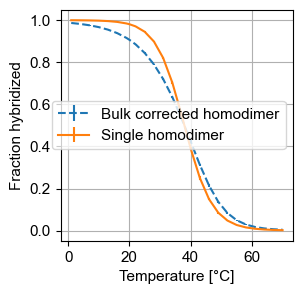

In [32]:

fig=plt.figure(figsize=(3,3))
plt.errorbar(final_temps_s,np.mean(all_f_inf,axis=0),yerr=np.std(all_f_inf,axis=0)/len(all_f_inf),label="Bulk corrected homodimer",fmt="--")

plt.errorbar(final_temps_s,np.mean(all_f_1,axis=0),yerr=np.std(all_f_1,axis=0)/len(all_f_1),label="Single homodimer")

plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
plt.ylabel(r"Fraction hybridized",fontname = "Arial",fontsize=11)
plt.xlabel("Temperature [°C]",fontname = "Arial",fontsize=11)
#plt.ylim(-2,6.5)
plt.grid()
plt.legend(prop={'family': 'Arial','size': 11})

In [33]:
print("Melting temperature, bulk corrected:",np.mean(return_temp_corr),"+/-",np.std(return_temp_corr)/len(return_temp_corr))
print("Melting temperature, not bulk corrected:",np.mean(return_temp),"+/-",np.std(return_temp)/len(return_temp))

print("Fraction hybrid. at 20°C, bulk corrected:",np.mean(return_fraction_corr),"+/-",np.std(return_fraction_corr)/len(return_fraction_corr))
print("Fraction hybrid. at 20°C, not bulk corrected:",np.mean(return_fraction),"+/-",np.std(return_fraction)/len(return_fraction))

Melting temperature, bulk corrected: 37.95262381161007 +/- 0.1660199004662706
Melting temperature, not bulk corrected: 37.97040180540869 +/- 0.16548950432883622
Fraction hybrid. at 20°C, bulk corrected: 0.9065925329680292 +/- 0.0023369976579711185
Fraction hybrid. at 20°C, not bulk corrected: 0.980645333551689 +/- 0.0008903487490382061


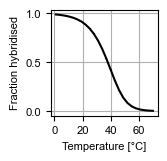

In [34]:
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)

plt.errorbar(final_temps_s,np.mean(all_f_inf,axis=0),yerr=np.std(all_f_inf,axis=0)/len(all_f_inf),label="Bulk corrected, homodimer",fmt="-",color="black")

fs1=8
#plt.xlim(-1,110)
#ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel(r"Fraction hybridised",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Temperature [°C]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,20,40,60],fontname = "Arial",fontsize=fs1)
plt.yticks([0.0,0.5,1.0],fontname = "Arial",fontsize=fs1)
ax1.grid()
#plt.savefig("/home/aaron/phd/oxDNA_1/oxDNA/x_motif_conrad_et_al/figures/metling_curve_SE_hybr_2.pdf",format="pdf",bbox_inches="tight")
